# Coursework Set Week 6

**Common remarks**:

* Deadline: Sunday at 23:59h for the week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Barbara Anna Chylinska
* Username: bachylinska
* Student number: s6480640
* Group (AS1, etc.): AS 5

-----

In [ ]:
totalpoints = currentpoints = 0

### Exploring a HI data cube (7 pt) <font color='red'><b>COURSEWORK</b></font>
   
* Download FITS image [ngc6946.fits](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/ngc6946.fits)
* Create a mosaic with 5 rows and 10 columns of channel maps for the Z indices ``range(1, 101, 2)``
* Remove axis labeling with Axes methods ``set_xticklabels([])`` and ``set_yticklabels([])``.
* If you add two channel maps you get a new map where each pixel is the sum of the two maps. If you add all channel maps (not the noisy ones), you get a so called *total HI* map.

    * Select a suitable range of channel maps and sum them to get a total HI map. Make a plot of this map
    * Label the axes with the header values of ``CTYPE1`` and ``CTYPE2``.
    * Make a locatable colorbar and label its Y axis with the header value of ``BUNIT``. 
        
* A *position velocity* (PV) map is a slice through the data at one fixed spatial position. 
   It tells you something about how the velocities in a galaxy behave as function of position 
   and one fixed position.   
   In NumPy jargon a PV map can be an YZ slice or a XZ slice. 

    * Plot a PV map for a fixed Right Ascension (R.A.) with index 50.
    * Plot a vertical line at Dec. with index 40.
    * Label the axes with the header values of ``CTYPE2`` and ``CTYPE3``. <br>&nbsp;</br>
        
* A *global HI spectral profile* is a slice in along the spectral axis at a fixed Right Ascension and Declination.
   It is a 1D curve with intensities as function of frequency (or velocity). It shows you at which 
   velocity most of the gas is rotating in a galaxy given a position in R.A. and Dec.

    * Plot a global profile at R.A. with index 50 and Dec. with index 40.
    * Label the plot axes with the header values of ``CTYPE3`` and ``BUNIT``. <br>&nbsp;</br>

* What is the relation between this profile and the vertical line in the previous plot of the PV diagram?   

**Answers**:

Filename: ngc6946.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     206   (100, 100, 101)   int16 (rescales to float32)   


Text(0, 0.5, 'JY/BEAM')

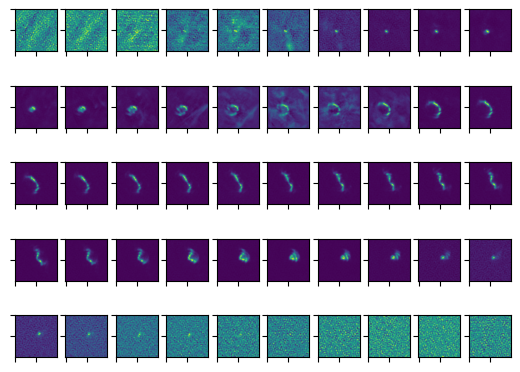

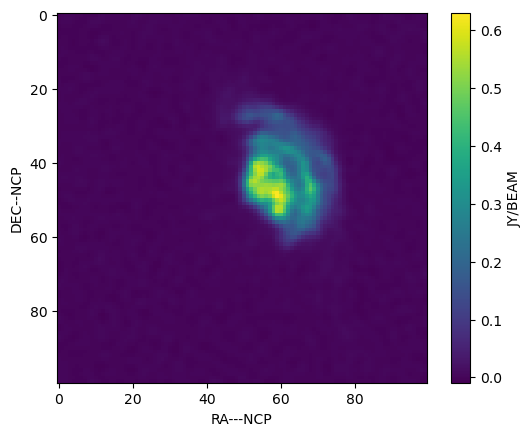

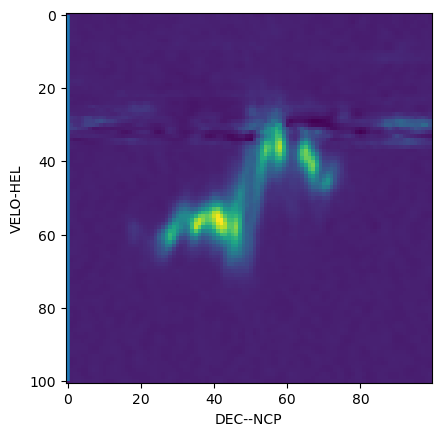

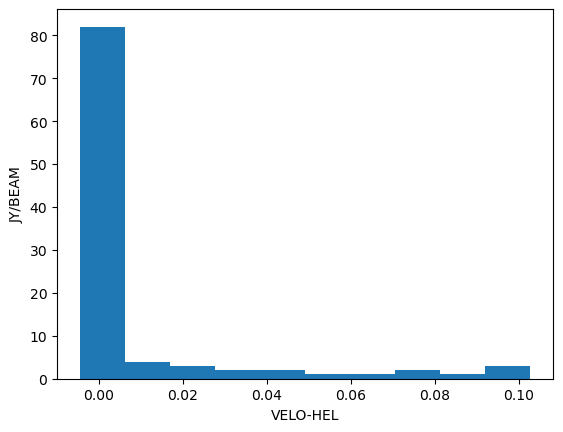

In [93]:
from scipy.special import jv
from matplotlib.pyplot import figure, show
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

hdulist = fits.open('ngc6946.fits')
hdulist.info()

dat = hdulist[0].data
hdr = hdulist[0].header
flat=dat.flatten()


fig = plt.figure()

A= np.arange(1, 101, 2)
m = np.reshape(A, (-1, 10))
mo =np.asarray(m,dtype=str)

   
ax_dict=fig.subplot_mosaic(mo,)
for n in np.ndarray.flatten(np.array(m)):
    ax_dict[str(n)].imshow(dat[n],label=str(n))
    ax_dict[str(n)].set_xticklabels([]) 
    ax_dict[str(n)].set_yticklabels([])
    


tot=np.stack(list(dat[i] for i in range(61,80,2)))
tot=np.sum(tot, axis=0)

plt.figure()
plt.imshow(tot)
plt.colorbar(label=hdr['BUNIT'])
plt.xlabel(hdr['CTYPE1'])
plt.ylabel(hdr['CTYPE2'])


plt.figure()
plt.imshow(dat[:,:,50])
plt.vlines(dat[:,40,50],0,100)
plt.xlabel(hdr['CTYPE2'])
plt.ylabel(hdr['CTYPE3'])

plt.figure()
plt.hist(dat[:,40,50])
plt.xlabel(hdr['CTYPE3'])
plt.ylabel(hdr['BUNIT'])

#for n in np.ndarray.flatten(np.array(m)):
    #ax_dict[n].legend()
    #ax_dict[n].set_title(f"Bessel's function {n}")
    #ax_dict[n].set_xlabel('x')
    #ax_dict[n].set_ylabel('y')

the line from the graph above corresponds to the fixed spatial coordinates along which the last graph is plotted

In [ ]:
# Leave unaltered
totalpoints += 7
currentpoints += 0.0

### Galaxy Colour (5 pt) <font color='red'><b>COURSEWORK</b></font>
   
Download [SDSS_DR17_galaxies.fits](https://brightspace.rug.nl/content/enforced/457626-WBAS018-05.2025-2026.1/SDSS_DR17_galaxies.fits), which contains apparent magnitude in ``u, g, r, i, z`` five SDSS broad-band filters.

* Create a Pandas DataFrame from the FITS table.
* Filter out any data with negative values.
* Calculate every combination of colours from each broad band filter, e.g. u-g, u-r, u-i, u-z, g-r, ......
* Calculate the mean and standard deviation of the each colour.
* Use Object-Oriented Plotting to create a corner plot using derived colours.
* Set the xlim and ylim to be within three standard deviation.
* Add title for each histogram with information of the mean and standard deviation of each colour in the format of $\mu\pm\sigma$
 (to one decimal place).

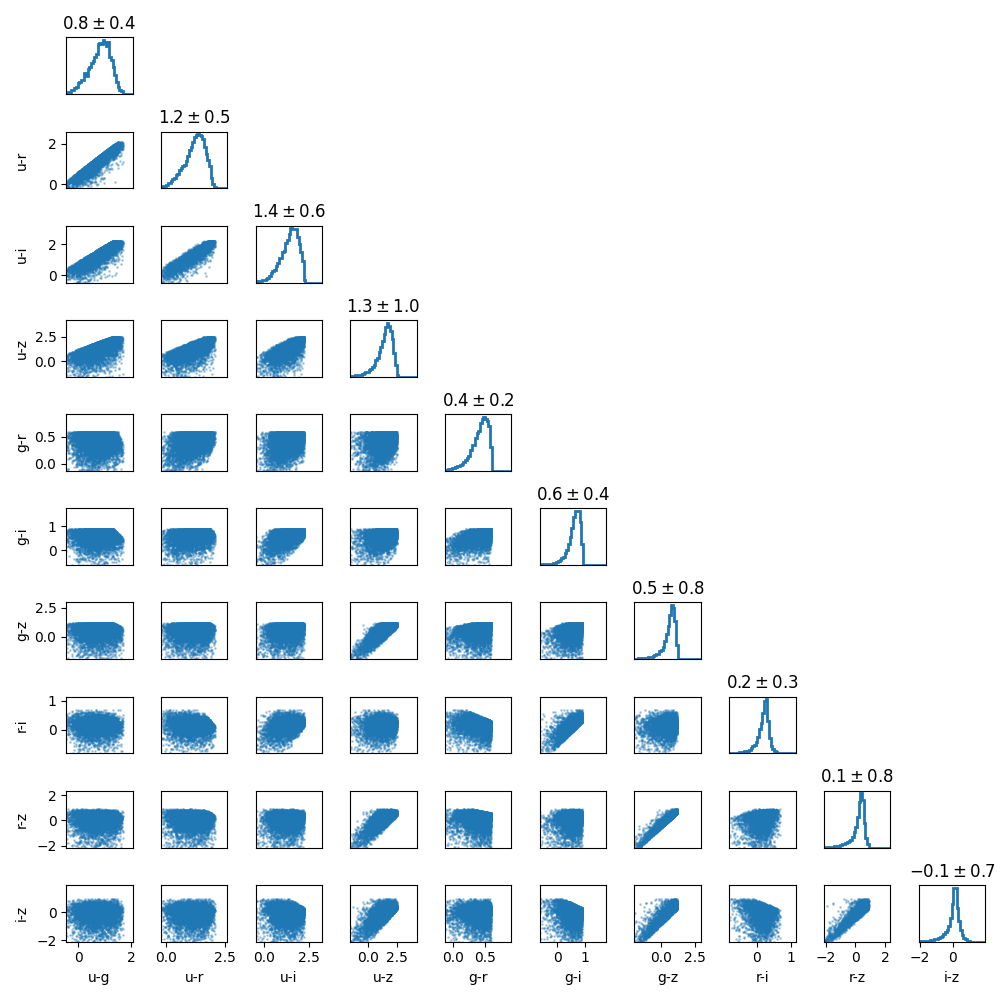
   
**Plot and answer**:

['ObjID', 'u', 'g', 'r', 'i', 'z']
(10, 10000)
[0.4174647033214569, 0.4684771001338959, 0.6080590486526489, 0.9628636240959167, 0.1767909973859787, 0.393960565328598, 0.8156567811965942, 0.32602623105049133, 0.7522957921028137, 0.6775551438331604]
[np.float32(0.8046083), np.float32(1.2026649), np.float32(1.3699306), np.float32(1.3112323), np.float32(0.39805645), np.float32(0.56532216), np.float32(0.5066239), np.float32(0.1672657), np.float32(0.108567454), np.float32(-0.058698256)]


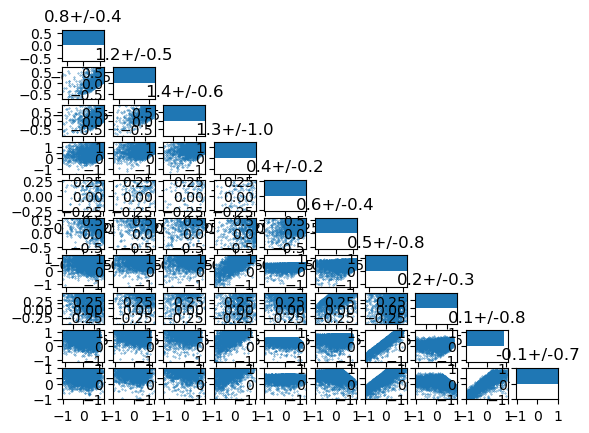

In [79]:
import pandas as pd
from astropy.table import Table
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt


t = Table.read('SDSS_DR17_galaxies.fits')
df = t.to_pandas()



df=df[df>0]
colours=[]
columns=df.columns.values.tolist()
print(columns)
for i in range(1,len(columns)):
    for j in range(i+1,len(columns)):
        colours.append(df[columns[i]]-df[columns[j]])
print(np.shape(colours))    

means=[]
stds=[]
for i in range(10):
    means.append(np.mean(colours[i]))
    stds.append(np.std(colours[i]))

print(stds)
print(means)

for i in range(10):
    for j in range(0,i+1):
        plt.subplot2grid((10,10), (i,j))
        plt.xlim([-1.5*stds[i], 1.5*stds[i]])
        plt.ylim([-1.5*stds[i], 1.5*stds[i]])

        if j<i:
            plt.scatter(colours[i],colours[j],s=0.1)
        else:
            plt.hist(colours[i])
            plt.title(f'{means[i]:.1f}+/-{stds[i]:.1f}')


    


In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Astroquery: retrieving SDSS image and spectra (5 pt) <font color='red'><b>COURSEWORK</b></font>

Spiral galaxy M77 (NGC 1068) is a bright galaxy known for hosting an active galactic nucleus (AGN). With Astropy package, we construct M77's coordinate using the code below.

```python
from astropy import coordinates as coords

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")
```

* Use ``astroquery`` ([search regions](https://astroquery.readthedocs.io/en/latest/sdss/sdss.html#searching-regions-and-multiple-objects)) on the ``pos``, containing RA and DEC of this galaxy, to retrieve its SDSS spectrum using ``get_spectra()``. The search radius sets as ``10 arcsec`` for searching.
* The return object of ``get_spectra()`` is a list of [HDUList](https://docs.astropy.org/en/stable/io/fits/api/hdulists.html#astropy.io.fits.HDUList) objects.
* Retrieve flux and wavelengths using columns ``flux`` and ``loglam``. Note that the wavelength is in logarithmic value, you need to convert it back to a linear scale.
* The redshift of M77 is approximately ``z~0.0038``. Calculating the rest-frame wavelengths.
* Use Object-Oriented Plotting to plot:
    * a rest-frame spectrum which corrects the redshift effect (top)
    * a zoom-in spectrum at wavelength between 6450 and 6650 angstrom (bottom)
* Draw vertical lines for H$\alpha$ lines in both frames. Label them and show with legend.
* Draw vertical lines indicating approximately where the peak of the flux is, which in fact should be the H$\alpha$ line.
* An example plot is shown below.
* Calculating the velocity indicated by the difference between the two wavelengths.
* Share your thought using a markdown on what might be causing this offset. This question will not be graded, and meant to train a bit your scientific thinking. Feel free to express any thought.

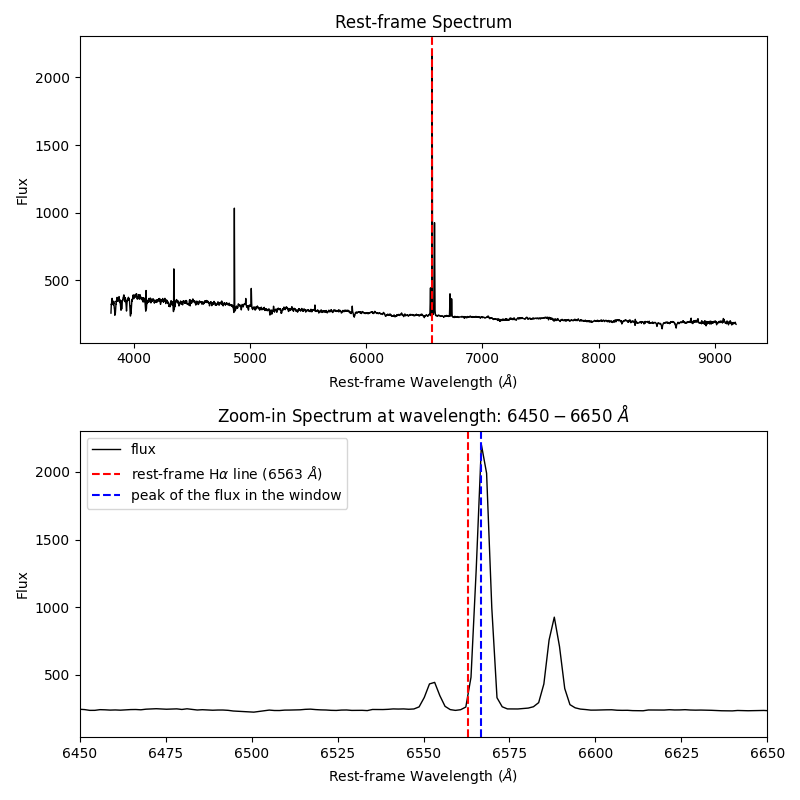

In [1]:
from astroquery.sdss import SDSS
from astropy import coordinates as coords
import numpy as np
from scipy.constants import c

# Coordinates of M77
ra = 40.6696  # degrees
dec = -0.0133  # degrees
pos = coords.SkyCoord(ra, dec, unit="deg", frame="icrs")

xid = SDSS.query_region(pos, radius='10 arcsec',spectro=True)
spect=get_spectra(xid)

flux= spect['flux']
loglam=np.array(spect['loglam'])
wav=10**loglam

z=0.0038
restwav=wav/(z+1)


fig1=plt.figure()
frame1 = fig1.add_subplot() 
frame1.plot(restwav,flux)
frame1.axvline(6562.8,label='H alpha')
plt.legend()

zoom=wav[6450<wav]
zoom=zoom[zoom<6650]
zoomy=flux[np.where(wav==6450),np.where(wav==6650)]

fig2=plt.figure()
frame2 = fig2.add_subplot() 
frame2.plot(zoom,zoomy)
frame2.axvline(6562.8,label='H alpha')
frame2.axvline(np.max(zoom),label='Peak flux in window')
plt.legend()

v=((np.max(zoom)-6562.8)*c/6562.8)


ModuleNotFoundError: No module named 'astroquery'

A moving galaxy will create a doppler effect for the wavelentgh- causing a shift between the expected wavelength and the observed one, as for a galaxy moving away the wave seems to stretch out, while for one moving closer it seems to shrink

In [ ]:
# Leave unaltered
totalpoints += 5
currentpoints += 0.0

### Comparing an image in different color scales (stretches) (4pt) <font color='red'><b>COURSEWORK</b></font>

Given is the Blaauw observatory FITS file
[20210422_Li_.00000066.FIT](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/20210422_Li_.00000066.FIT)

Use the `imdisplay()` function from the notebook *The art of plotting an image* to make a mosaic with this image using all the different scales (stretches) available to that function. 

* Add a proper docstring to the function.
* Show the used scale in the title of the plot. (hints: tight_layout, fontsize).
* Also include the image without scaling as the first plot in the mosaic.

**Answer**:

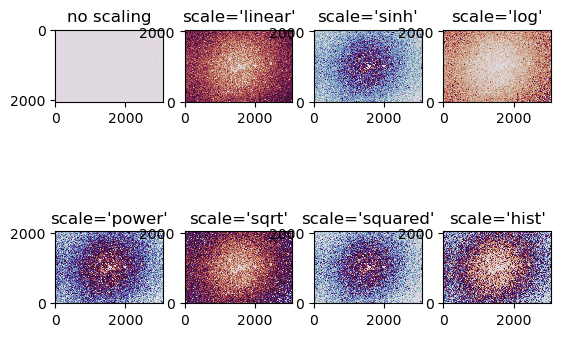

In [109]:
from astropy.visualization import ImageNormalize
from astropy.visualization import SinhStretch, AsymmetricPercentileInterval, LinearStretch,\
                                  LogStretch, PowerStretch, SqrtStretch, SquaredStretch,\
                                  HistEqStretch, ZScaleInterval

hdulist = fits.open('20210422_Li_.00000066.FIT')

dat = hdulist[0].data
hdr = hdulist[0].header
flat=dat.flatten()

def imdisplay(data,
              ax,
              vmin=None, vmax=None,
              percentlow=1, percenthigh=99,
              zscale=False,
              scale='linear',
              power=1.5,
              cmap='gray',
              **kwargs):
    if zscale:
        # Always overwrite vmin and vmax
        interval = ZScaleInterval()
        vmin, vmax = interval.get_limits(data)
    if vmin is None or vmax is None:
        interval = AsymmetricPercentileInterval(percentlow, percenthigh)
        vmin2, vmax2 = interval.get_limits(data)
        if vmin is None:
            vmin = vmin2
        if vmax is None:
            vmax = vmax2

    if scale == 'linear':
        stretch = LinearStretch(slope=0.5, intercept=0.5)
    if scale == 'sinh':
        stretch = SinhStretch()
    if scale == 'log':
        stretch = LogStretch()
    if scale == 'power':
        stretch = PowerStretch(power)
    if scale == 'sqrt':
        stretch = SqrtStretch()
    if scale == 'squared':
        stretch = SquaredStretch()
    if scale == 'hist':
        stretch = HistEqStretch(data)  # Needs argument data and data min, max for vmin, vmax
        vmin = data.min(); vmax = data.max()

    norm = ImageNormalize(vmin=vmin, vmax=vmax, stretch=stretch)
    return ax.imshow(data, interpolation='none', origin='lower', norm=norm, cmap=cmap, **kwargs)



fig = plt.figure()

m="""
QABC
DEFH
"""

   
ax_dict=fig.subplot_mosaic(m,)
ax_dict['Q'].imshow(dat, cmap='twilight')
imdisplay(dat, ax_dict['A'], cmap='twilight')
imdisplay(dat, ax_dict['B'], scale='sinh', cmap='twilight')
imdisplay(dat, ax_dict['C'], scale='log', cmap='twilight')
imdisplay(dat, ax_dict['D'], scale='power', cmap='twilight')
imdisplay(dat, ax_dict['E'], scale='sqrt', cmap='twilight')
imdisplay(dat, ax_dict['F'], scale='squared', cmap='twilight')
imdisplay(dat, ax_dict['H'], scale='hist', cmap='twilight')
ax_dict['A'].set_title("scale='linear'")
ax_dict['B'].set_title("scale='sinh'")
ax_dict['C'].set_title("scale='log'")
ax_dict['D'].set_title("scale='power'")
ax_dict['E'].set_title("scale='sqrt'")
ax_dict['F'].set_title("scale='squared'")
ax_dict['H'].set_title("scale='hist'")
ax_dict['Q'].set_title("no scaling")

show()

    




In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Image stacking optical data (6pt) <font color='red'><b>COURSEWORK</b></font>

Select one of the suitable observations from the next table or
find one yourself in the
[Blaauw Observatory Overview](https://www.astro.rug.nl/intranet/sterrenwacht/files.py)

* Following the stacking procedure in the notebook about image stacking for the data you selected. Show the result.
* Align the images and repeat the stacking procedure. Show the result.
* Remove all unnecessary code and markdown text.
* Include code and result in your report.

| nr | Folder on data server |
| :---  | :---: |
| 2  | ``/net/dataserver3/data/users/sterrenwacht/images/210418/STL-6303E/i/`` |
| 3  | ``/net/dataserver3/data/users/sterrenwacht/images/190515/STL-6303E/i/`` |
| 4  | ``/net/dataserver3/data/users/sterrenwacht/images/190428/STL-6303E/i/`` |
| 5  | ``/net/dataserver3/data/users/sterrenwacht/images/190419/STL-6303E/i/`` |
| 6  | ``/net/dataserver3/data/users/sterrenwacht/images/180504/STL-6303E/i/`` |
| 7  | ``/net/dataserver3/data/users/sterrenwacht/images/160913/STL-6303E/i/`` |
| 8  | ``/net/dataserver3/data/users/sterrenwacht/images/140912/STL-6303E/i/`` |
| 9  | ``/net/dataserver3/data/users/sterrenwacht/images/131001/STL-6303E/i/`` |
| 10 | ``/net/dataserver3/data/users/sterrenwacht/images/101212/STL-6303E/i/`` |

**Code and plot**:

In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")